In [1]:
from sports.configs.soccer import SoccerPitchConfiguration


In [2]:
config = SoccerPitchConfiguration()

In [3]:
config

SoccerPitchConfiguration(width=7000, length=12000, penalty_box_width=4100, penalty_box_length=2015, goal_box_width=1832, goal_box_length=550, centre_circle_radius=915, penalty_spot_distance=1100, edges=[(1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (7, 8), (10, 11), (11, 12), (12, 13), (14, 15), (15, 16), (16, 17), (18, 19), (19, 20), (20, 21), (23, 24), (25, 26), (26, 27), (27, 28), (28, 29), (29, 30), (1, 14), (2, 10), (3, 7), (4, 8), (5, 13), (6, 17), (14, 25), (18, 26), (23, 27), (24, 28), (21, 29), (17, 30)], labels=['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '15', '16', '17', '18', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '14', '19'], colors=['#FF1493', '#FF1493', '#FF1493', '#FF1493', '#FF1493', '#FF1493', '#FF1493', '#FF1493', '#FF1493', '#FF1493', '#FF1493', '#FF1493', '#FF1493', '#00BFFF', '#00BFFF', '#00BFFF', '#00BFFF', '#FF6347', '#FF6347', '#FF6347', '#FF6347', '#FF6347', '#FF6347', '#FF6347', '#FF6347', '#

In [4]:
config.length

12000

In [5]:
config.width

7000

In [6]:
config.penalty_box_width

4100

In [7]:
config.goal_box_length

550

In [8]:
type(config.vertices)

list

In [9]:
config.edges

[(1, 2),
 (2, 3),
 (3, 4),
 (4, 5),
 (5, 6),
 (7, 8),
 (10, 11),
 (11, 12),
 (12, 13),
 (14, 15),
 (15, 16),
 (16, 17),
 (18, 19),
 (19, 20),
 (20, 21),
 (23, 24),
 (25, 26),
 (26, 27),
 (27, 28),
 (28, 29),
 (29, 30),
 (1, 14),
 (2, 10),
 (3, 7),
 (4, 8),
 (5, 13),
 (6, 17),
 (14, 25),
 (18, 26),
 (23, 27),
 (24, 28),
 (21, 29),
 (17, 30)]

In [10]:
from inference import get_model


/home/sharaf/enviroments/ai_latest/lib/python3.12/site-packages/inference/core/env.py:196: InferenceDeprecationWarning: CORE_MODEL_GAZE_ENABLED is True: POST /gaze/gaze_detection is registered as a deprecation stub returning HTTP 410 Gone. The stub and this flag will be removed end of Q2 2026. Set CORE_MODEL_GAZE_ENABLED=False to disable it now.
  warnings.warn(
ModelDependencyMissing: Your `inference` configuration does not support SAM model. Use pip install 'inference[sam]' to install missing requirements.To suppress this warning, set CORE_MODEL_SAM_ENABLED to False.
ModelDependencyMissing: Your `inference` configuration does not support SAM3 model. Install SAM3 dependencies and set CORE_MODEL_SAM3_ENABLED to True.
[transformers] `DepthProImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `DepthProImageProcessor` instead.


In [ ]:

FIELD_DETECTION_MODEL = get_model(model_id=FIELD_DETECTION_MODEL_ID, api_key=ROBOFLOW_API_KEY)

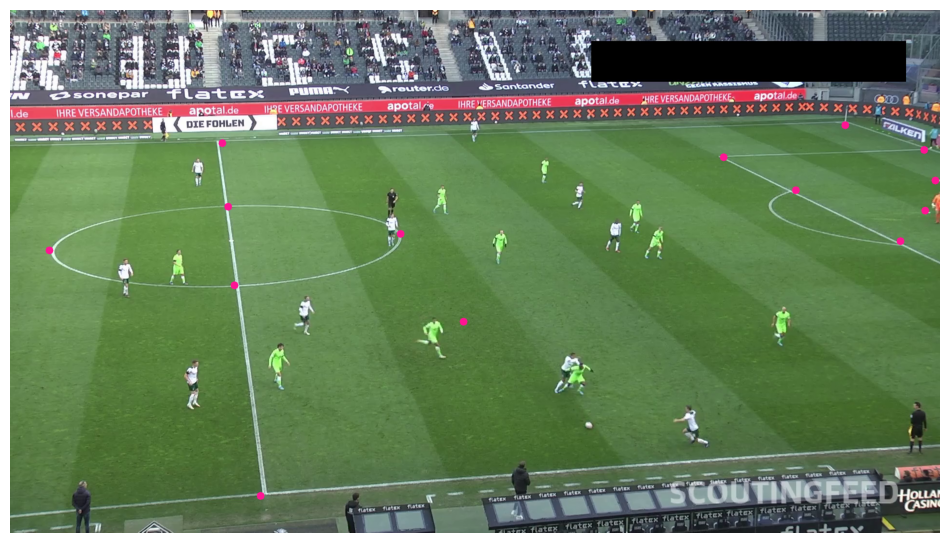

In [12]:
import supervision as sv
SOURCE_VIDEO_PATH = "../data/videos/input/08fd33_4.mp4"

vertex_annotator = sv.VertexAnnotator(
    color=sv.Color.from_hex('#FF1493'),
    radius=8)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

result = FIELD_DETECTION_MODEL.infer(frame, confidence=0.3)[0]
key_points = sv.KeyPoints.from_inference(result)

annotated_frame = frame.copy()
annotated_frame = vertex_annotator.annotate(
    scene=annotated_frame,
    key_points=key_points)

sv.plot_image(annotated_frame)

In [13]:
result

KeypointsDetectionInferenceResponse(visualization=None, inference_id=None, frame_id=None, time=None, image=InferenceResponseImage(width=1920, height=1080), predictions=[KeypointsPrediction(x=960.0, y=641.5, width=1918.0, height=835.0, confidence=0.9833564758300781, class_name='pitch', class_confidence=None, class_id=0, tracker_id=None, detection_id='9995ac44-4f2e-4366-9f08-a3aa03888211', parent_id=None, keypoints=[Keypoint(x=-532.0, y=314.0, confidence=1.2546777725219727e-05, class_id=0, class_name='01'), Keypoint(x=-600.0, y=364.0, confidence=6.854534149169922e-07, class_id=1, class_name='02'), Keypoint(x=-697.0, y=430.0, confidence=1.1920928955078125e-07, class_id=2, class_name='03'), Keypoint(x=936.0, y=644.0, confidence=5.960464477539063e-08, class_id=5, class_name='06'), Keypoint(x=-626.0, y=435.0, confidence=3.2782554626464844e-07, class_id=6, class_name='07'), Keypoint(x=-639.0, y=507.0, confidence=4.470348358154297e-07, class_id=8, class_name='09'), Keypoint(x=-388.0, y=374.0, 

In [14]:
import cv2

from inference import get_model

MODEL_ID = "football-field-detection-f07vi/14"

model = get_model(
    model_id=MODEL_ID,
    api_key=ROBOFLOW_API_KEY,
)

In [15]:
import sys
sys.path.append('../')

In [16]:
from src.field.pitch_detector import *


In [17]:

detector = RoboflowPitchDetector(
    api_key=ROBOFLOW_API_KEY,
    model_id=MODEL_ID,
    confidence_threshold=0.3,
)

In [18]:
result = detector.detect(frame)


In [19]:

print("=" * 50)
print(f"Detected Keypoints : {result.num_keypoints}")
print("=" * 50)

for kp in result.keypoints:
    print(
        f"Class: {kp.class_id:2d} | "
        f"X: {kp.x:7.1f} | "
        f"Y: {kp.y:7.1f} | "
        f"Conf: {kp.confidence:.3f}"
    )

Detected Keypoints : 13
Class: 13 | X:   438.0 | Y:   276.0 | Conf: 0.997
Class: 14 | X:   450.0 | Y:   407.0 | Conf: 0.999
Class: 15 | X:   463.0 | Y:   569.0 | Conf: 0.999
Class: 16 | X:   517.0 | Y:  1003.0 | Conf: 0.855
Class: 17 | X:  1473.0 | Y:   305.0 | Conf: 0.997
Class: 18 | X:  1622.0 | Y:   373.0 | Conf: 0.986
Class: 19 | X:  1838.0 | Y:   478.0 | Conf: 0.733
Class: 21 | X:  1889.0 | Y:   415.0 | Conf: 0.582
Class: 22 | X:  1910.0 | Y:   353.0 | Conf: 0.529
Class: 24 | X:  1724.0 | Y:   239.0 | Conf: 0.919
Class: 25 | X:  1887.0 | Y:   290.0 | Conf: 0.597
Class: 30 | X:    81.0 | Y:   497.0 | Conf: 0.812
Class: 31 | X:   806.0 | Y:   463.0 | Conf: 1.000


In [44]:
import matplotlib.pyplot as plt

annotated_frame = []
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
for frame in frame_generator:
    image = frame.copy()
    result = detector.detect(frame)
    for kp in result.keypoints:

        x = int(kp.x)
        y = int(kp.y)

        cv2.circle(
            image,
            (x, y),
            6,
            (0,255,0),
            -1,
        )

        cv2.putText(
            image,
            str(kp.class_id),
            (x+8, y-8),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0,0,255),
            2,
        )

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    annotated_frame.append(image)

In [50]:
image_annotaed = []
for image in annotated_frame:
    image_annotaed.append(cv2.cvtColor(image, cv2.COLOR_RGB2BGR))


In [51]:
import os
import cv2

def images_to_video(images, output_video_path, fps=25):
    if len(images) == 0:
        raise ValueError("No images provided.")

    # Create output directory if it doesn't exist
    os.makedirs(os.path.dirname(output_video_path), exist_ok=True)

    height, width = images[0].shape[:2]

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    video_writer = cv2.VideoWriter(
        output_video_path,
        fourcc,
        fps,
        (width, height)
    )

    print(f"Writing {len(images)} frames to {output_video_path}...")

    for frame in images:
        video_writer.write(frame)

    video_writer.release()
    print("Done!")

images_to_video(annotated_frame, "data/videos/output/res.mp4")

Writing 750 frames to data/videos/output/res.mp4...
Done!


In [48]:
len(annotated_frame)

750

In [21]:
from src.field.pitch_config import *


In [22]:
config = PitchConfiguration()

for kp in result.keypoints:

    world = config.get_point(kp.class_id)

    print(
        f"Class {kp.class_id:2d}"
        f" -> Image ({kp.x:.0f},{kp.y:.0f})"
        f" -> World ({world.x:.0f},{world.y:.0f})"
    )

Class 13 -> Image (438,276) -> World (6000,0)
Class 14 -> Image (450,407) -> World (6000,2585)
Class 15 -> Image (463,569) -> World (6000,4415)
Class 16 -> Image (517,1003) -> World (6000,7000)
Class 17 -> Image (1473,305) -> World (9985,1450)
Class 18 -> Image (1622,373) -> World (9985,2584)
Class 19 -> Image (1838,478) -> World (9985,4416)
Class 21 -> Image (1889,415) -> World (10900,3500)
Class 22 -> Image (1910,353) -> World (11450,2584)
Class 24 -> Image (1724,239) -> World (12000,0)
Class 25 -> Image (1887,290) -> World (12000,1450)
Class 30 -> Image (81,497) -> World (5085,3500)
Class 31 -> Image (806,463) -> World (6915,3500)


In [23]:
image_points = result.image_points()

world_points = np.array(
    [
        (config.get_point(kp.class_id).x,
         config.get_point(kp.class_id).y)
        for kp in result.keypoints
    ],
    dtype=np.float32,
)

print(image_points.shape)
print(world_points.shape)

(13, 2)
(13, 2)


In [24]:
for kp, wp in zip(result.keypoints, world_points):
    print(
        kp.class_id,
        (kp.x, kp.y),
        tuple(wp)
    )

13 (438.0, 276.0) (np.float32(6000.0), np.float32(0.0))
14 (450.0, 407.0) (np.float32(6000.0), np.float32(2585.0))
15 (463.0, 569.0) (np.float32(6000.0), np.float32(4415.0))
16 (517.0, 1003.0) (np.float32(6000.0), np.float32(7000.0))
17 (1473.0, 305.0) (np.float32(9985.0), np.float32(1450.0))
18 (1622.0, 373.0) (np.float32(9985.0), np.float32(2584.0))
19 (1838.0, 478.0) (np.float32(9985.0), np.float32(4416.0))
21 (1889.0, 415.0) (np.float32(10900.0), np.float32(3500.0))
22 (1910.0, 353.0) (np.float32(11450.0), np.float32(2584.0))
24 (1724.0, 239.0) (np.float32(12000.0), np.float32(0.0))
25 (1887.0, 290.0) (np.float32(12000.0), np.float32(1450.0))
30 (81.0, 497.0) (np.float32(5085.0), np.float32(3500.0))
31 (806.0, 463.0) (np.float32(6915.0), np.float32(3500.0))


In [25]:
import cv2

H, mask = cv2.findHomography(
    image_points,
    world_points,
    method=cv2.RANSAC,
)

print(H)
print(mask.sum())

[[     10.513      45.761      1106.1]
 [     2.0385       80.23      -23036]
 [ -0.0002162   0.0077966           1]]
5


In [26]:
predicted_world = cv2.perspectiveTransform(
    image_points.reshape(-1, 1, 2),
    H,
).reshape(-1, 2)

for gt, pred in zip(world_points, predicted_world):
    print(
        f"GT: ({gt[0]:8.1f}, {gt[1]:8.1f})   "
        f"Pred: ({pred[0]:8.1f}, {pred[1]:8.1f})"
    )

GT: (  6000.0,      0.0)   Pred: (  5999.3,      0.0)
GT: (  6000.0,   2585.0)   Pred: (  6001.5,   2584.6)
GT: (  6000.0,   4415.0)   Pred: (  5999.0,   4414.8)
GT: (  6000.0,   7000.0)   Pred: (  6021.8,   6716.4)
GT: (  9985.0,   1450.0)   Pred: (  9985.0,   1450.1)
GT: (  9985.0,   2584.0)   Pred: (  9902.4,   2866.1)
GT: (  9985.0,   4416.0)   Pred: (  9771.1,   4402.6)
GT: ( 10900.0,   3500.0)   Pred: ( 10440.2,   3686.8)
GT: ( 11450.0,   2584.0)   Pred: ( 11182.1,   2748.7)
GT: ( 12000.0,      0.0)   Pred: ( 12112.4,   -139.3)
GT: ( 12000.0,   1450.0)   Pred: ( 11992.6,   1429.0)
GT: (  5085.0,   3500.0)   Pred: (  5085.2,   3500.4)
GT: (  6915.0,   3500.0)   Pred: (  6936.4,   3551.6)


In [27]:
errors = np.linalg.norm(
    predicted_world - world_points,
    axis=1,
)

print("Mean Error :", errors.mean())
print("Max Error  :", errors.max())

Mean Error : 143.40521
Max Error  : 496.318


In [28]:
errors = np.linalg.norm(
    predicted_world - world_points,
    axis=1,
)

for kp, err in zip(result.keypoints, errors):
    print(
        kp.class_id,
        round(err,2)
    )

13 0.7
14 1.55
15 1.03
16 284.39
17 0.11
18 293.92
19 214.28
21 496.32
22 314.41
24 178.99
25 22.24
30 0.48
31 55.84


In [29]:
print(mask.ravel())

[1 1 1 0 1 0 0 0 0 0 0 1 0]


In [30]:
from src.field.homography import HomographyEstimator

estimator = HomographyEstimator()

homography = estimator.estimate(
    detections=result,
    pitch=config,
)

print(homography.matrix)

print(homography.num_inliers)

[[     4.2379      37.474      2614.3]
 [    -0.4436      65.081      -17769]
 [-0.00065641   0.0063642           1]]
5


In [31]:
player = np.array(
    [[[950, 700]]],
    dtype=np.float32,
)

world = cv2.perspectiveTransform(
    player,
    homography.matrix,
)

print(world)

[[[     6803.9      5664.4]]]


In [32]:
predicted = cv2.perspectiveTransform(
    image_points.reshape(-1,1,2),
    homography.matrix
).reshape(-1,2)

print(predicted)

[[     5999.7    -0.16093]
 [     6001.3      2585.8]
 [     5998.9      4414.1]
 [     6018.2      6711.9]
 [      10276      723.25]
 [      10162      2506.2]
 [     9985.9        4417]
 [      10899      3499.2]
 [      12012      2186.8]
 [      13586       -2144]
 [      13366      166.75]
 [     5251.3      3538.1]
 [     6841.3      3513.2]]


In [33]:
world_points

array([[       6000,           0],
       [       6000,        2585],
       [       6000,        4415],
       [       6000,        7000],
       [       9985,        1450],
       [       9985,        2584],
       [       9985,        4416],
       [      10900,        3500],
       [      11450,        2584],
       [      12000,           0],
       [      12000,        1450],
       [       5085,        3500],
       [       6915,        3500]], dtype=float32)

In [34]:
point = np.array(
    [[[950, 700]]],
    dtype=np.float32,
)

world = cv2.perspectiveTransform(
    point,
    homography.matrix,
)

image = cv2.perspectiveTransform(
    world,
    homography.inverse_matrix,
)

print("Original :", point.reshape(-1, 2))
print("Recovered:", image.reshape(-1, 2))

Original : [[        950         700]]
Recovered: [[        950         700]]


In [35]:
from src.field.transformer import CoordinateTransformer

transformer = CoordinateTransformer(homography)

In [36]:
point = (950, 700)

world = transformer.image_to_world(point)

print(world)

(6803.9013671875, 5664.42578125)


In [37]:
image = transformer.world_to_image(world)

print(image)

(950.0, 700.0)


In [41]:
from src.analytics.distance import DistanceCalculator

calculator = DistanceCalculator()

In [42]:
p1 = (0, 0)
p2 = (3000, 4000)

print(
    calculator.calculate(
        p1,
        p2,
    )
)

5.0


In [43]:
path = [
    (0, 0),
    (3000, 4000),
    (6000, 4000),
]

print(
    calculator.calculate_path(path)
)

8.0


In [1]:
import sys
sys.path.append('../')

In [2]:
import cv2

from src.field.pitch_config import PitchConfiguration
from src.field.pitch_detector import RoboflowPitchDetector
from src.field.camera_estimator import CameraEstimator

/home/sharaf/enviroments/ai_latest/lib/python3.12/site-packages/inference/core/env.py:196: InferenceDeprecationWarning: CORE_MODEL_GAZE_ENABLED is True: POST /gaze/gaze_detection is registered as a deprecation stub returning HTTP 410 Gone. The stub and this flag will be removed end of Q2 2026. Set CORE_MODEL_GAZE_ENABLED=False to disable it now.
  warnings.warn(
ModelDependencyMissing: Your `inference` configuration does not support SAM model. Use pip install 'inference[sam]' to install missing requirements.To suppress this warning, set CORE_MODEL_SAM_ENABLED to False.
ModelDependencyMissing: Your `inference` configuration does not support SAM3 model. Install SAM3 dependencies and set CORE_MODEL_SAM3_ENABLED to True.
[transformers] `DepthProImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `DepthProImageProcessor` instead.


In [3]:
VIDEO_PATH = "/home/sharaf/Desktop/Football-Analyzer/data/videos/input/08fd33_4.mp4"

API_KEY = "Tkf5r6l0lO9jbpH73gwt"
MODEL_ID = "football-field-detection-f07vi/14"   # example

In [4]:
pitch = PitchConfiguration()

detector = RoboflowPitchDetector(
    api_key=API_KEY,
    model_id=MODEL_ID,
    confidence_threshold=0.5,
)

camera = CameraEstimator(
    detector=detector,
    pitch=pitch,
)

In [5]:
OUTPUT_PATH = "/home/sharaf/Desktop/Football-Analyzer/data/videos/output/res1.mp4"

In [6]:
cap = cv2.VideoCapture(VIDEO_PATH)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

writer = cv2.VideoWriter(
    OUTPUT_PATH,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height),
)

frame_id = 0

# --------------------------------------------------
# Processing
# --------------------------------------------------

while True:

    ret, frame = cap.read()

    if not ret:
        break

    camera.update(frame)

    detections = camera.detections
    homography = camera.homography

    annotated = frame.copy()

    # ------------------------------
    # Draw Keypoints
    # ------------------------------

    for kp in detections.keypoints:

        x = int(kp.x)
        y = int(kp.y)

        cv2.circle(
            annotated,
            (x, y),
            5,
            (0, 255, 0),
            -1,
        )

        cv2.putText(
            annotated,
            str(kp.class_id),
            (x + 5, y - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (0, 255, 255),
            1,
        )

    # ------------------------------
    # Information
    # ------------------------------

    cv2.putText(
        annotated,
        f"Frame: {frame_id}",
        (20, 35),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 0, 0),
        2,
    )

    cv2.putText(
        annotated,
        f"Keypoints: {detections.num_keypoints}",
        (20, 70),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 0, 0),
        2,
    )

    cv2.putText(
        annotated,
        f"Inliers: {homography.num_inliers}",
        (20, 105),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 0, 0),
        2,
    )

    writer.write(annotated)

    frame_id += 1

# --------------------------------------------------
# Finish
# --------------------------------------------------

cap.release()
writer.release()

print(f"Saved to: {OUTPUT_PATH}")

Saved to: /home/sharaf/Desktop/Football-Analyzer/data/videos/output/res1.mp4
